# Modelo Base de Machine Learning 

---

## 📌 ¿Por qué necesitamos un modelo base?  

Un **modelo base** (o *baseline*) es esencial porque:  
1. **Establece un punto de referencia mínimo** para comparar modelos más complejos.  
2. **Ayuda a detectar problemas tempranos**: Si tu modelo avanzado no supera al baseline, hay un error en el enfoque.  
3. **Simplifica la complejidad inicial**: Usa reglas heurísticas basadas en análisis exploratorios (EDA).  

> 🔍 *Ejemplo práctico*: En el Titanic, sabemos por datos históricos que mujeres y niños tuvieron prioridad en los botes.  

---

## 🛠️ Modelo Base Propuesto  

### Reglas heurísticas (basadas en el análisis EDA):  
```python
if (sex == "female") and (pclass < 3): 
    survived = 1  # Sobrevive
elif (age <= 5) or (10 <= age <= 15):
    survived = 1  # Sobrevive
else:
    survived = 0  # No sobrevive

# Importación de Librerías

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# Carga de datos

In [2]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

datos_titanic = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_titanic.parquet", engine="pyarrow")

In [3]:
print("Pandas version: ", pd.__version__)

Pandas version:  2.2.3


# Preparación de los datos

Basado en lñas reglas mencionadas, solo se necesitarán 3 columnas: sex, pclass, edad.

In [4]:
selected_features = ["sex", "pclass", "age", "survived"]

titanic_features = datos_titanic[selected_features]

titanic_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   sex       1309 non-null   category
 1   pclass    1309 non-null   int64   
 2   age       1046 non-null   float64 
 3   survived  1309 non-null   bool    
dtypes: bool(1), category(1), float64(1), int64(1)
memory usage: 23.3 KB


In [5]:
titanic_features.isna().sum()

sex           0
pclass        0
age         263
survived      0
dtype: int64

Se debe convertir la variable objetivo a valores numéricos.

In [6]:
titanic_features.loc[:, "survived"] = titanic_features["survived"].astype(int)

/tmp/ipykernel_71869/2647647274.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  titanic_features.loc[:, "survived"] = titanic_features["survived"].astype(int)


Analicemos los datos duplicados:

In [8]:
len(titanic_features.drop_duplicates())

434

Para el modelo base, no eliminaremos duplicados, ya que en futuros modelos que imputemos o que hagamos alguna transformación, puede ser importante conservar un buen volumen de datos. Tener en cuenta que esto ocurre porque se eliminaron varias columnas, entonces las que quedan tienen una alta probabilidad de repetirse.

In [9]:
titanic_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   sex       1309 non-null   category
 1   pclass    1309 non-null   int64   
 2   age       1046 non-null   float64 
 3   survived  1309 non-null   int64   
dtypes: category(1), float64(1), int64(2)
memory usage: 32.2 KB


In [10]:
titanic_features.sample(10, random_state=42)

,sex,pclass,age,survived
1148,male,3,35.0,0
1049,male,3,20.0,1
982,male,3,NaN,0
808,male,3,NaN,0
1195,male,3,NaN,0
240,male,1,45.0,1
1118,male,3,25.0,0
596,male,2,31.0,1
924,male,3,34.5,0
65,female,1,33.0,1


# Ingeniería de datos

In [11]:
cols_numeric = ["age"]
cols_categoric = ["sex"]
cols_categoric_ord = ["pclass"]

Vamos a imputar con la mediana algunos registros de la columna "age".

In [12]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

In [ ]:
# El orden del preprocesador en el pipeline sí importa

preprocessor = ColumnTransformer(
    transformers=[
        # passthrough significa que esas columnas pasan directamente al output sin transformaciones
        ("categoric", "passthrough", cols_categoric),
        # passthrough significa que esas columnas pasan directamente al output sin transformaciones
        ("categoric ordinal", "passthrough", cols_categoric_ord),
        ("numeric", numeric_pipe, cols_numeric),
    ]
)

In [14]:
preprocessor

ColumnTransformer(transformers=[('categoric', 'passthrough', ['sex']),
                                ('categoric ordinal', 'passthrough',
                                 ['pclass']),
                                ('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age'])])

## Ejemplo de los datos preprocesados

In [15]:
data_example = titanic_features.sample(5, random_state=42)
data_example

,sex,pclass,age,survived
1148,male,3,35.0,0
1049,male,3,20.0,1
982,male,3,NaN,0
808,male,3,NaN,0
1195,male,3,NaN,0


In [16]:
preprocessor.fit_transform(data_example)

array([['male', 3, 35.0],
       ['male', 3, 20.0],
       ['male', 3, 27.5],
       ['male', 3, 27.5],
       ['male', 3, 27.5]], dtype=object)

# Separación en entrenamiento y prueba

In [17]:
X_features = titanic_features.drop("survived", axis="columns")
Y_target = titanic_features["survived"]

In [18]:
# 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target
)
x_train.shape, y_train.shape

((1047, 3), (1047,))

In [19]:
x_test.shape, y_test.shape

((262, 3), (262,))

# Modelo

In [24]:
class HeuristicModel(BaseEstimator, ClassifierMixin):
    """Modelo heurístico para el Titanic"""

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        SEX = "female"
        PCLASS_THRESHOLD = 3
        AGE_THRESHOLD_1 = 5
        AGE_THRESHOLD_2_LOW = 10
        AGE_THRESHOLD_2_HIGH = 15
        predictions = []
        for input in X:
            if (
                (input[0] == SEX) & (input[1] < PCLASS_THRESHOLD)
                or (input[2] <= AGE_THRESHOLD_1)
                or (
                    (input[2] >= AGE_THRESHOLD_2_LOW)
                    & (input[2] <= AGE_THRESHOLD_2_HIGH)
                )
            ):
                predictions.append(1)
            else:
                predictions.append(0)
        return np.array(predictions)

In [22]:
x_train

,sex,pclass,age
305,male,1,60.0
257,female,1,35.0
1117,male,3,21.0
1155,male,3,NaN
268,male,1,24.0
...,...,...,...
723,male,3,31.0
434,female,2,7.0
61,female,1,76.0
378,male,2,31.0


# Predicción y evaluación

In [25]:
# Modelo

model = HeuristicModel()

In [26]:
# Métricas de evaluación

scoring_metrics = ["accuracy", "f1", "precision", "recall"]

In [27]:
# Validación cruzada

kfold = KFold(n_splits=10)

In [28]:
# Pipeline del modelo

model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

In [29]:
# Para guardar los resultados de la validación cruzada

cv_results = {}
train_results = {}

In [ ]:
# Resultado de la evaluación cruzada por cada métrica

for metric in scoring_metrics:

    # Evaluación en el set de validación cruzada
    cv_results[metric] = cross_val_score(
        model_pipe, x_train, y_train, cv=kfold, scoring=metric
    )

    # Evaluación en el set de entrenamiento
    model_pipe.fit(x_train, y_train)
    train_results[metric] = model_pipe.score(x_train, y_train)

# Resultados en un  dataframe
cv_results_df = pd.DataFrame(cv_results)

In [31]:
cv_results_df

,accuracy,f1,precision,recall
0,0.771429,0.625000,0.740741,0.540541
1,0.752381,0.617647,0.875000,0.477273
2,0.790476,0.725000,0.966667,0.580000
3,0.723810,0.539683,0.772727,0.414634
4,0.780952,0.735632,0.888889,0.627451
5,0.809524,0.615385,0.888889,0.470588
6,0.752381,0.535714,0.652174,0.454545
7,0.846154,0.741935,0.920000,0.621622
8,0.836538,0.711864,0.954545,0.567568
9,0.817308,0.688525,0.840000,0.583333


In [33]:
for metric_name in scoring_metrics:
    print(
        f"{metric_name} - CV mean: {cv_results_df[metric_name].mean()}, "
        f"CV std: {cv_results_df[metric_name].std()}"
    )
    print(f"{metric_name} - Train score: {train_results[metric_name]}")

accuracy - CV mean: 0.7880952380952382, CV std: 0.03950842330922248
accuracy - Train score: 0.7879656160458453
f1 - CV mean: 0.653638516432758, CV std: 0.07795302657239157
f1 - Train score: 0.7879656160458453
precision - CV mean: 0.849963182550139, CV std: 0.10013011633457626
precision - Train score: 0.7879656160458453
recall - CV mean: 0.5337554606908983, CV std: 0.0744831386922739
recall - Train score: 0.7879656160458453


<Axes: title={'center': 'Cross Validation Boxplot'}, ylabel='Score'>

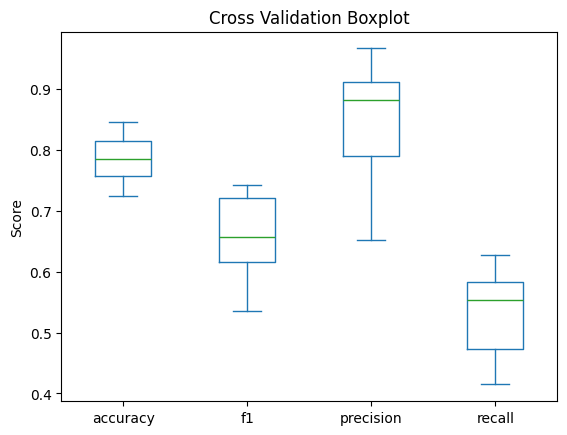

In [35]:
# Box plot de cada métrica
cv_results_df.plot.box(title="Cross Validation Boxplot", ylabel="Score")

In [36]:
# Crear un dataframe para el entrenamiento y las metricas de validacion cruzada

metrics_df = pd.DataFrame(
    {
        "Metric": scoring_metrics,
        "Train Score": [train_results[metric] for metric in scoring_metrics],
        "CV Mean": [cv_results_df[metric].mean() for metric in scoring_metrics],
        "CV Std": [cv_results_df[metric].std() for metric in scoring_metrics],
    }
)

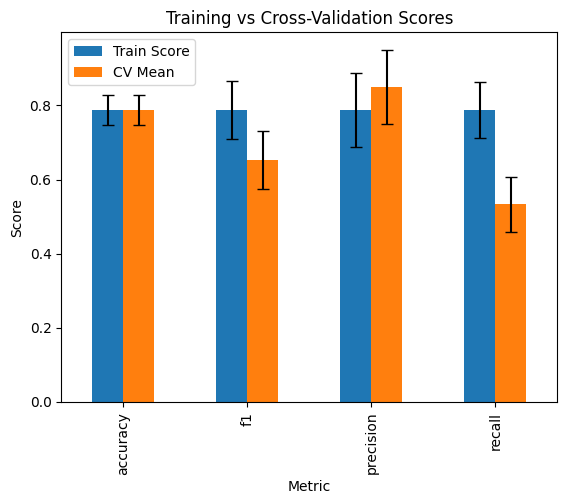

In [37]:
# Bar plot para comparar ambas métricas

metrics_df.plot(
    kind="bar",
    x="Metric",
    y=["Train Score", "CV Mean"],
    yerr="CV Std",
    title="Training vs Cross-Validation Scores",
    ylabel="Score",
    capsize=4,
);

# Evaluación final

In [39]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

y_pred = model_pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.84       162
           1       0.79      0.57      0.66       100

    accuracy                           0.78       262
   macro avg       0.78      0.74      0.75       262
weighted avg       0.78      0.78      0.77       262



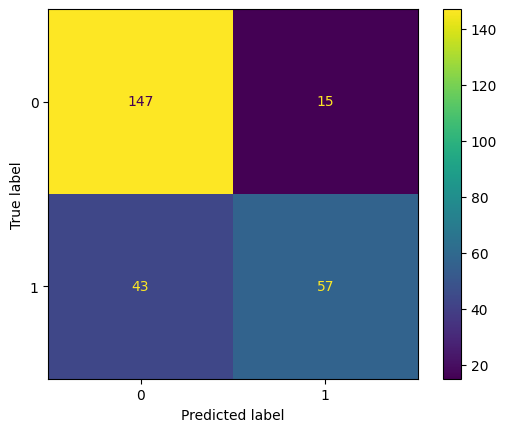

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);